In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import re

from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from fastai.text.all import *

sns.set_style("whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [6]:
categories = [
    "comp.graphics",
    "rec.sport.baseball",
    "sci.med",
    "talk.politics.misc"
]

dataset = fetch_20newsgroups(
    subset='all',
    categories=categories,
    remove=('headers','footers','quotes')
)

texts = dataset.data
labels = dataset.target
label_names = dataset.target_names

print("Total samples:", len(texts))

Total samples: 3732


In [7]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\n',' ',text)
    text = re.sub(r'[^a-zA-Z ]',' ',text)
    text = re.sub(r'\s+',' ',text)
    return text

texts = [clean_text(t) for t in texts]

In [8]:
MAX_PER_CLASS = 1000

df = pd.DataFrame({
    "text": texts,
    "label": labels
})

df = df.groupby("label").head(MAX_PER_CLASS).reset_index(drop=True)

print("Dataset size after constraints:", len(df))

Dataset size after constraints: 3732


In [9]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df["label"]
)

print(len(train_df), "training samples")
print(len(test_df), "test samples")

2985 training samples
747 test samples


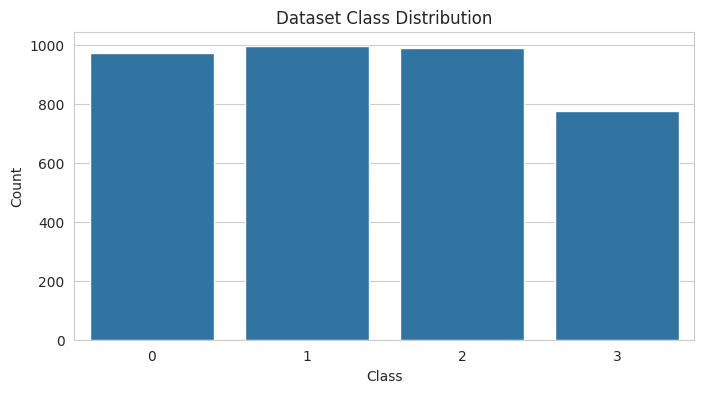

In [10]:
plt.figure(figsize=(8,4))

sns.countplot(x=df["label"])

plt.title("Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [11]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words="english"
)

X_train = vectorizer.fit_transform(train_df["text"])
X_test = vectorizer.transform(test_df["text"])

In [12]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, train_df["label"])

lr_preds = lr_model.predict(X_test)

traditional_acc = accuracy_score(test_df["label"], lr_preds)

print("Traditional NLP Accuracy:", traditional_acc)

Traditional NLP Accuracy: 0.8969210174029452


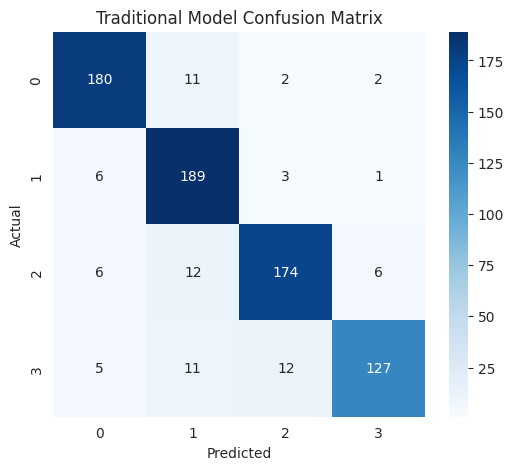

In [13]:
cm = confusion_matrix(test_df["label"], lr_preds)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Traditional Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [14]:
train_df_fastai = train_df.copy()
test_df_fastai = test_df.copy()

train_df_fastai["label"] = train_df_fastai["label"].astype(str)
test_df_fastai["label"] = test_df_fastai["label"].astype(str)

df_fastai = pd.concat([train_df_fastai, test_df_fastai])

In [15]:
dls = TextDataLoaders.from_df(
    df_fastai,
    text_col="text",
    label_col="label",
    valid_pct=0.2,
    seed=SEED
)

In [16]:
learn = text_classifier_learner(
    dls,
    AWD_LSTM,
    drop_mult=0.5,
    metrics=accuracy
)

learn.fine_tune(3)

<div><progress max="105067061" value="105070592"></progress> 100.00% [105070592/105067061 00:10&lt;00:00]</div>

epoch,train_loss,valid_loss,accuracy,time
0,0.853578,0.527600,0.824397,00:16


epoch,train_loss,valid_loss,accuracy,time
0,0.553558,0.433664,0.835121,00:30
1,0.462338,0.377594,0.856568,00:31
2,0.386728,0.405120,0.857909,00:30


In [17]:
dl_preds, dl_targets = learn.get_preds()

dl_pred_labels = dl_preds.argmax(dim=1)

deep_acc = accuracy_score(dl_targets, dl_pred_labels)

print("ULMFiT Deep Learning Accuracy:", deep_acc)

ULMFiT Deep Learning Accuracy: 0.8579088471849866


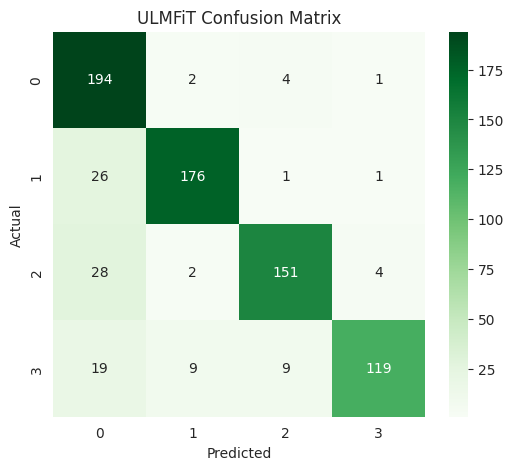

In [18]:
cm_dl = confusion_matrix(dl_targets, dl_pred_labels)

plt.figure(figsize=(6,5))

sns.heatmap(cm_dl, annot=True, fmt="d", cmap="Greens")

plt.title("ULMFiT Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

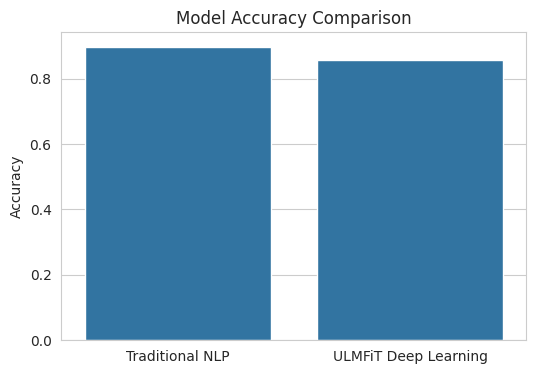

In [19]:
models = ["Traditional NLP", "ULMFiT Deep Learning"]
scores = [traditional_acc, deep_acc]

plt.figure(figsize=(6,4))

sns.barplot(x=models, y=scores)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

In [20]:
print("Traditional Model Report")
print(classification_report(test_df["label"], lr_preds))

print("Deep Learning Model Report")
print(classification_report(dl_targets, dl_pred_labels))

Traditional Model Report
              precision    recall  f1-score   support

           0       0.91      0.92      0.92       195
           1       0.85      0.95      0.90       199
           2       0.91      0.88      0.89       198
           3       0.93      0.82      0.87       155

    accuracy                           0.90       747
   macro avg       0.90      0.89      0.90       747
weighted avg       0.90      0.90      0.90       747

Deep Learning Model Report
              precision    recall  f1-score   support

           0       0.73      0.97      0.83       201
           1       0.93      0.86      0.90       204
           2       0.92      0.82      0.86       185
           3       0.95      0.76      0.85       156

    accuracy                           0.86       746
   macro avg       0.88      0.85      0.86       746
weighted avg       0.88      0.86      0.86       746

